In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt

In [2]:
file_path = "../data/processed/superstore_clean.csv"

df = pd.read_csv(file_path)

In [3]:
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country_region,city,...,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [4]:
df.shape

(10194, 21)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   row_id          10194 non-null  int64  
 1   order_id        10194 non-null  str    
 2   order_date      10194 non-null  str    
 3   ship_date       10194 non-null  str    
 4   ship_mode       10194 non-null  str    
 5   customer_id     10194 non-null  str    
 6   customer_name   10194 non-null  str    
 7   segment         10194 non-null  str    
 8   country_region  10194 non-null  str    
 9   city            10194 non-null  str    
 10  state_province  10194 non-null  str    
 11  postal_code     10194 non-null  str    
 12  region          10194 non-null  str    
 13  product_id      10194 non-null  str    
 14  category        10194 non-null  str    
 15  sub_category    10194 non-null  str    
 16  product_name    10194 non-null  str    
 17  sales           10194 non-null  float64
 1

In [6]:
df["order_date"] = pd.to_datetime(df["order_date"]) # Date columns: convert from string to datetime.
df["ship_date"] = pd.to_datetime(df["ship_date"]) 

df.dtypes # Correct format is verified.

row_id                     int64
order_id                     str
order_date        datetime64[us]
ship_date         datetime64[us]
ship_mode                    str
customer_id                  str
customer_name                str
segment                      str
country_region               str
city                         str
state_province               str
postal_code                  str
region                       str
product_id                   str
category                     str
sub_category                 str
product_name                 str
sales                    float64
quantity                   int64
discount                 float64
profit                   float64
dtype: object

In [7]:
# Temporary variables are created for analysis
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["month_name"] = df["order_date"].dt.month_name()

df[["order_date", "year", "month", "month_name"]].head() # Temporary variables generated → Verified.

,order_date,year,month,month_name
0,2023-01-03,2023,1,January
1,2023-01-04,2023,1,January
2,2023-01-04,2023,1,January
3,2023-01-04,2023,1,January
4,2023-01-05,2023,1,January


In [8]:
# Business metrics are created.
df["sales_per_unit"] = df["sales"] / df["quantity"]
df["profit_margin"] = df["profit"] / df["sales"]

df.head() # Business metrics verified

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country_region,city,...,product_name,sales,quantity,discount,profit,year,month,month_name,sales_per_unit,profit_margin
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512,2023,1,January,8.224,0.3375
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870,2023,1,January,1.770,-1.5500
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Avery 508,11.784,3,0.2,4.2717,2023,1,January,3.928,0.3625
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748,2023,1,January,90.912,-0.2375
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840,2023,1,January,6.512,0.2500


In [9]:
# Extreme Values Review
df[["sales", "profit", "discount"]].describe()

,sales,profit,discount
count,10194.000000,10194.000000,10194.000000
mean,228.225854,28.673417,0.155385
std,619.906839,232.465115,0.206249
min,0.444000,-6599.978000,0.000000
25%,17.220000,1.760800,0.000000
50%,53.910000,8.690000,0.200000
75%,209.500000,29.297925,0.200000
max,22638.480000,8399.976000,0.800000


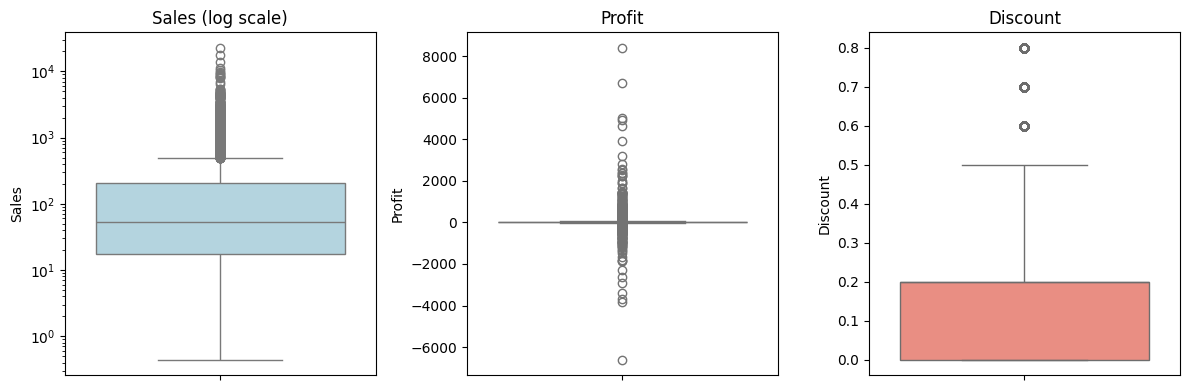

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Verificación básica del dataframe
required_cols = ["sales", "profit", "discount"]
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"Faltan columnas en el DataFrame: {missing_cols}")

# Crear figura y ejes
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))

# Boxplot Sales
sns.boxplot(y=df["sales"], ax=axes[0], showfliers=True, color="lightblue")
axes[0].set_yscale("log")
axes[0].set_title("Sales (log scale)")
axes[0].set_ylabel("Sales")

# Boxplot Profit
sns.boxplot(y=df["profit"], ax=axes[1], color="lightgreen")
axes[1].set_title("Profit")
axes[1].set_ylabel("Profit")

# Boxplot Discount
sns.boxplot(y=df["discount"], ax=axes[2], color="salmon")
axes[2].set_title("Discount")
axes[2].set_ylabel("Discount")

# Ajustar layout y mostrar
plt.tight_layout()
plt.show()

In [11]:
# Extreme Sales

Q1 = df["sales"].quantile(0.25)
Q3 = df["sales"].quantile(0.75)

IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR

df["outliers_sales"] = (df["sales"] < lower_limit) | (df["sales"] > upper_limit)

df["outliers_sales"]

0        False
1        False
2        False
3        False
4        False
         ...  
10189    False
10190    False
10191    False
10192    False
10193    False
Name: outliers_sales, Length: 10194, dtype: bool

In [12]:
# Extreme Profits

Q1 = df["profit"].quantile(0.25)
Q3 = df["profit"].quantile(0.75)

IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR

# outliers_profit = df[(df["profit"] < lower_limit) | (df["profit"] > upper_limit)]
df["outliers_profit"] = (df["profit"] < lower_limit) | (df["profit"] > upper_limit)

# outliers_profit
df["outliers_profit"] 

0        False
1        False
2        False
3         True
4        False
         ...  
10189    False
10190    False
10191    False
10192    False
10193    False
Name: outliers_profit, Length: 10194, dtype: bool

In [13]:
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country_region', 'city',
       'state_province', 'postal_code', 'region', 'product_id', 'category',
       'sub_category', 'product_name', 'sales', 'quantity', 'discount',
       'profit', 'year', 'month', 'month_name', 'sales_per_unit',
       'profit_margin', 'outliers_sales', 'outliers_profit'],
      dtype='str')

In [ ]:
# Column list to CSV.
columns_for_dashboard = [
    'order_date',
    'region',
    'state_province',
    'city',
    'category',
    'sub_category', 
    'product_name', 
    'sales', 
    'quantity', 
    'discount',
    'profit',
    'year', 
    'month', 
    'month_name', 
    'sales_per_unit',
    'profit_margin', 
    'outliers_sales', 
    'outliers_profit'
]

df_dashboard = df[columns_for_dashboard]
df_dashboard

,order_date,region,country_region,city,category,sub_category,product_name,sales,quantity,discount,profit,year,month,month_name,sales_per_unit,profit_margin,outliers_sales,outliers_profit
0,2023-01-03,Central,United States,Houston,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512,2023,1,January,8.224,0.3375,False,False
1,2023-01-04,Central,United States,Naperville,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870,2023,1,January,1.770,-1.5500,False,False
2,2023-01-04,Central,United States,Naperville,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717,2023,1,January,3.928,0.3625,False,False
3,2023-01-04,Central,United States,Naperville,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748,2023,1,January,90.912,-0.2375,False,True
4,2023-01-05,East,United States,Philadelphia,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840,2023,1,January,6.512,0.2500,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10189,2026-12-30,East,United States,New York City,Office Supplies,Binders,Wilson Jones Legal Size Ring Binders,52.776,3,0.2,19.7910,2026,12,December,17.592,0.3750,False,False
10190,2026-12-30,West,United States,Fairfield,Office Supplies,Binders,GBC Binding covers,20.720,2,0.2,6.4750,2026,12,December,10.360,0.3125,False,False
10191,2026-12-30,West,United States,Loveland,Office Supplies,Fasteners,Bagged Rubber Bands,3.024,3,0.2,-0.6048,2026,12,December,1.008,-0.2000,False,False
10192,2026-12-30,East,United States,New York City,Technology,Phones,Gear Head AU3700S Headset,90.930,7,0.0,2.7279,2026,12,December,12.990,0.0300,False,False


In [15]:
df_dashboard.shape

(10194, 18)

In [16]:

csv_output_path = "../data/processed/superstore_dashboard.csv"
parquet_output_path = "../data/processed/superstore_dashboard.parquet"
df_dashboard.to_csv(csv_output_path, index=False)
df_dashboard.to_parquet(
    parquet_output_path,
    engine="pyarrow",
    index=False
)
print(f"dataset_dashboard ok")

dataset_dashboard ok
